In [1]:
!pip install -U datasets huggingface_hub fsspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 9.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface-hub 0.34.3
    Uninstalling huggingface-hub-0.34.3:
      Successfully uninstalled huggingface-hub-0.34.3


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import math
import datasets
import requests

## Dataset and Tokenizer


In [31]:
dataset = datasets.load_dataset("wmt/wmt14", "de-en", split=["train", "test"])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

de-en/train-00000-of-00003.parquet:   0%|          | 0.00/280M [00:00<?, ?B/s]

de-en/train-00001-of-00003.parquet:   0%|          | 0.00/265M [00:00<?, ?B/s]

de-en/train-00002-of-00003.parquet:   0%|          | 0.00/273M [00:00<?, ?B/s]

de-en/validation-00000-of-00001.parquet:   0%|          | 0.00/474k [00:00<?, ?B/s]

de-en/test-00000-of-00001.parquet:   0%|          | 0.00/509k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4508785 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3003 [00:00<?, ? examples/s]

In [ ]:
df = pd.DataFrame(dataset[0]["translation"])

In [13]:
unk_idx = 0
pad_idx = 1
sos_idx = 2
eos_idx = 3

### Train Tokenizer

In [12]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace, Punctuation, Sequence as Pre_Seq
from tokenizers.normalizers import Lowercase, Sequence
from tokenizers.processors import TemplateProcessing
from tokenizers.normalizers import Sequence, NFC, Lowercase
from copy import deepcopy

tkz_en = Tokenizer(BPE(unk_token="[UNK]"))
tkz_en.normalizer = Sequence([NFC(), Lowercase()])
tkz_en.pre_tokenizer = Pre_Seq([Whitespace(), Punctuation()])
tkz_en.post_processor = TemplateProcessing(
    single="[SOS] $A [EOS]",
    special_tokens=[("[SOS]", sos_idx), ("[EOS]", eos_idx)],
)
tkz_de = deepcopy(tkz_en)
trainer = BpeTrainer(vocab_size=30000, special_tokens=["[UNK]", "[PAD]", "[SOS]", "[EOS]"])

In [ ]:
training_data_de = df["de"].to_list()
training_data_en = df["en"].to_list()
import numpy as np
np.random.shuffle(training_data_de)
np.random.shuffle(training_data_en)

In [ ]:
tkz_en.train_from_iterator(training_data_en, trainer)
tkz_de.train_from_iterator(training_data_de, trainer)

In [ ]:
tkz_en.save("tokenizer_en.json")
tkz_de.save("tokenizer_de.json")

### Load Tokenizer

In [14]:
text = requests.get("https://raw.githubusercontent.com/TheGEN1U5/DLventures/refs/heads/main/nlp/seq2seq/tokenizer_en.json").text
with open("tokenizer_en.json", "w") as f:
    f.write(text)
text = requests.get("https://raw.githubusercontent.com/TheGEN1U5/DLventures/refs/heads/main/nlp/seq2seq/tokenizer_de.json").text
with open("tokenizer_de.json", "w") as f:
    f.write(text)

In [15]:
tkz_en = Tokenizer.from_file("tokenizer_en.json")
tkz_de = Tokenizer.from_file("tokenizer_de.json")

### Tokenize Data

In [ ]:
original_df = deepcopy(df)

In [ ]:
# taking only 100k rows
df = original_df[:170000]
df["de_len"] = df["de"].apply(lambda x: len(x))
df["en_len"] = df["en"].apply(lambda x: len(x))

In [ ]:
df.drop(df[df['en_len'] > 200].index, inplace=True)
df.drop(df[df['de_len'] > 200].index, inplace=True)

In [ ]:
df["de_tokens"] = df["de"].apply(lambda x: torch.tensor(tkz_de.encode(x).ids, dtype=torch.long))
df["en_tokens"] = df["en"].apply(lambda x: torch.tensor(tkz_en.encode(x).ids, dtype=torch.long))


### Sampling Function

In [ ]:
from sklearn.model_selection import train_test_split
def sample(df, size, val_split):
    num_bins = 10  # increase/decrease depending on precision vs sample size tradeoff
    df['bin'] = pd.cut(df['en_len'], bins=num_bins)
    sampled_df = (
        df.groupby('bin', group_keys=False)
        .apply(lambda x: x.sample(frac=size / len(df), random_state=42))
    )
    train_df, val_df = train_test_split(
        sampled_df,
        test_size=val_split,  # 20% goes to val+test
        stratify=sampled_df['bin'],
        random_state=42
    )
    return train_df, val_df

### Create Loaders

In [ ]:
def collate_fn(batch):
    en, de = zip(*batch)
    padded_en = pad_sequence(en, batch_first=True, padding_value=pad_idx)
    padded_de = pad_sequence(de, batch_first=True, padding_value=pad_idx)
    return padded_en, padded_de

In [ ]:
def get_loader(df, batch_size):
    return DataLoader(list(zip(df["en_tokens"].to_numpy(), df["de_tokens"].to_numpy())), batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

## Transformer


### Implementation

In [3]:
class PositionalEmbedding(nn.Module):
    def __init__(self, max_seq_len, embed_dim):
        super(PositionalEmbedding, self).__init__()
        self.embed_dim = embed_dim
        pos_mask = torch.zeros((max_seq_len, embed_dim))
        for pos in range(max_seq_len):
            for i in range(0, self.embed_dim, 2):
                pos_mask[pos, i] = np.sin(pos / 10000 ** (i / self.embed_dim))
                pos_mask[pos, i + 1] = np.cos(pos / 10000 ** (i / self.embed_dim))

        pos_mask = pos_mask.unsqueeze(0)
        self.register_buffer("pos_mask", pos_mask)

    def forward(self, x):
        seq_len = x.size(1)
        x = x + torch.autograd.Variable(self.pos_mask[:,:seq_len], requires_grad=False)
        return x

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, key_dim, value_dim, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.embed_dim = embed_dim
        self.e = embed_dim // num_heads
        self.d_k = key_dim
        self.d_v = value_dim
        self.k_proj = nn.ModuleList([nn.Linear(self.e, self.d_k) for _ in range(num_heads)])
        self.q_proj = nn.ModuleList([nn.Linear(self.e, self.d_k) for _ in range(num_heads)])
        self.v_proj = nn.ModuleList([nn.Linear(self.e, self.d_v) for _ in range(num_heads)])
        self.out = nn.Linear(self.num_heads * self.d_v, self.embed_dim)

    def forward(self, key, query, value, mask=None):
        self.mask = mask

        b_k, s_k, _ = key.size()
        b_q, s_q, _ = query.size()
        b_v, s_v, _ = value.size()
        key = key.reshape(b_k, s_k, self.num_heads, self.e)
        query = query.reshape(b_q, s_q, self.num_heads, self.e)
        value = value.reshape(b_v, s_v, self.num_heads, self.e)

        k = torch.stack([proj(key[:, :, i, :]) for i, proj in enumerate(self.k_proj)], dim=2)  # [n, l, h, d_k]
        q = torch.stack([proj(query[:, :, i, :]) for i, proj in enumerate(self.q_proj)], dim=2)
        v = torch.stack([proj(value[:, :, i, :]) for i, proj in enumerate(self.v_proj)], dim=2)

        qkt_scaled = torch.einsum("nqhd,nkhd->nhqk", q, k) / math.sqrt(self.d_k)
        if mask is not None:
            qkt_scaled = qkt_scaled.masked_fill(mask == 0, float("-1e20"))
        sftmx = torch.softmax(qkt_scaled, dim=-1)

        scores = torch.einsum("nhqk,nkhd->nqhd", sftmx, v)
        concat = scores.reshape(b_q, s_q, -1)

        output = self.out(concat)
        return output

In [5]:
class Encoder(nn.Module):
    def __init__(self, embed_dim, key_dim, value_dim, num_heads):
        super(Encoder, self).__init__()
        self.embed_dim = embed_dim
        self.d_k = key_dim
        self.d_v = value_dim
        self.num_heads = num_heads

        self.MHA = MultiHeadAttention(self.embed_dim, self.d_k, self.d_v, self.num_heads)
        self.norm1 = nn.LayerNorm(self.embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(self.embed_dim, 2 * self.embed_dim),
            nn.ReLU(),
            nn.Linear(2 * self.embed_dim, self.embed_dim)
        )
        self.norm2 = nn.LayerNorm(self.embed_dim)
        self.drop1 = nn.Dropout(0.1)
        self.drop2 = nn.Dropout(0.1)

    def forward(self, x):
        mha_output = self.MHA(x, x, x)
        add_norm1 = self.norm1(mha_output + self.drop1(x))
        ffn_output = self.ffn(add_norm1)
        output = self.norm2(ffn_output + self.drop2(add_norm1))
        return output

In [6]:
class Decoder(nn.Module):
    def __init__(self, embed_dim, key_dim, value_dim, num_heads):
        super(Decoder, self).__init__()
        self.embed_dim = embed_dim
        self.d_k = key_dim
        self.d_v = value_dim
        self.num_heads = num_heads

        self.masked_MHA = MultiHeadAttention(self.embed_dim, self.d_k, self.d_v, self.num_heads)
        self.norm1 = nn.LayerNorm(self.embed_dim)
        self.cross_MHA = MultiHeadAttention(self.embed_dim, self.d_k, self.d_v, self.num_heads)
        self.norm2 = nn.LayerNorm(self.embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(self.embed_dim, 2 * self.embed_dim),
            nn.ReLU(),
            nn.Linear(2 * self.embed_dim, self.embed_dim)
        )
        self.norm3 = nn.LayerNorm(self.embed_dim)
        self.drop1 = nn.Dropout(0.1)
        self.drop2 = nn.Dropout(0.1)
        self.drop3 = nn.Dropout(0.1)

    def forward(self, x, enc_output):
        batch_size, trg_len, _ = x.shape
        # returns the lower triangular part of matrix filled with ones
        mask = torch.tril(torch.ones((trg_len, trg_len),  device=x.device)).expand(
            batch_size, 1, trg_len, trg_len
        )
        masked_mha_output = self.masked_MHA(x, x, x, mask=mask)
        add_norm1 = self.norm1(masked_mha_output + self.drop1(x))
        cross_mha_output = self.cross_MHA(enc_output, add_norm1, enc_output)
        add_norm2 = self.norm2(cross_mha_output + self.drop2(add_norm1))
        ffn_output = self.ffn(add_norm2)
        output = self.norm3(ffn_output + self.drop3(add_norm2))
        # print("dec_output_type", output.dtype)
        return output

In [7]:
class Transformer(nn.Module):
    def __init__(self, embed_dim, vocab_size_src, vocab_size_tgt, key_dim, value_dim, num_heads, num_encoder_layers=1, num_decoder_layers=1, max_seq_len=100):
        super(Transformer, self).__init__()
        self.embedding_src = nn.Embedding(vocab_size_src, embed_dim, padding_idx=1)
        self.embedding_trg = nn.Embedding(vocab_size_tgt, embed_dim, padding_idx=1)
        self.pe = PositionalEmbedding(max_seq_len, embed_dim)
        self.encoder_layers = nn.ModuleList([
            Encoder(embed_dim, key_dim, value_dim, num_heads)
            for _ in range(num_encoder_layers)
        ])
        self.decoder_layers = nn.ModuleList([
            Decoder(embed_dim, key_dim, value_dim, num_heads)
            for _ in range(num_encoder_layers)
        ])
        self.out = nn.Linear(embed_dim, vocab_size_tgt)

    def forward(self, x, y):
        v_x = self.embedding_src(x)
        v_x = self.pe(v_x)
        v_y = self.embedding_trg(y)
        v_y = self.pe(v_y)
        for layer in self.encoder_layers:
            v_x = layer(v_x)
        for layer in self.decoder_layers:
            v_y = layer(v_y, v_x)
        logits = self.out(v_y)
        probs = torch.softmax(logits, dim=-1)
        preds = probs.max(dim=-1).indices
        return logits

### Training loop

In [8]:
def train(model, device, train_loader, val_loader, num_epochs=10, learning_rate=1e-3, pad_idx=0, early_stop=False):
    model.to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.98), eps=1e-9)

    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    patience_counter = 0
    patience_limit = 10
    best_model_state = None

    for epoch in tqdm(range(num_epochs)):
        # Training
        model.train()
        total_loss = 0

        for batch_idx, (src, tgt) in enumerate(train_loader):
            src = src.to(device)
            tgt = tgt.to(device)

            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            logits = model(src, tgt_input)
            # print(logits.dtype, tgt_output.dtype)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for src, tgt in val_loader:
                src = src.to(device)
                tgt = tgt.to(device)

                tgt_input = tgt[:, :-1]
                tgt_output = tgt[:, 1:]

                logits = model(src, tgt_input)
                loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Early stopping logic
        if early_stop:
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                best_model_state = model.state_dict()
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience_limit:
                    print(f"Early stopping triggered at epoch {epoch+1}")
                    if best_model_state is not None:
                        model.load_state_dict(best_model_state)
                    return train_losses, val_losses

    if early_stop and best_model_state is not None:
        model.load_state_dict(best_model_state)

    return train_losses, val_losses


# Scaling Laws
https://arxiv.org/abs/2001.08361

## Law 1
### Performance with Non-Embedding Parameter Count N

$$
L(N) \approx \left( \frac{N_c}{N} \right) ^{α_N}
$$


According to this law, given that the dataset size and the compute budget is fixed, the Loss follows a power law of N (the number of non-embedding parameters)

**Calculation of Non-Embedding Parameters for basic transformers**
$$
N \approx 12n_{layer}d_{model}^2
$$

So, we will use 3 different transformer model sizes to demonstrate this power law.
The dataset size would be way less than the original paper and hence α may not completely match.

But, there is one caveat. We need to fix Compute ($C \approx 6\cdot N\cdot B\cdot S$) for each of these models.

Since, $ C \propto N \cdot S $ (if we keep the batch size and dataset fixed), therefore we will need to reduce the number of epochs accordingly for each model. Also, $S \propto n_{epochs}$ so, finally $ C \propto N \cdot n_{epochs } $

**Models Used**
- **Tiny**
    
    $d_{model} = 64$, $ n_h = 4 $, $ n_{layer} = 2 $
    
    So, $ N \approx 12 \cdot 2 \cdot 64^2 \approx 0.09M $

    $n_{epochs} = 9$

- **Small**
    
    $d_{model} = 128$, $ n_h = 4 $, $ n_{layer} = 2 $
    
    So, $ N \approx 12 \cdot 2 \cdot 128^2 \approx 0.39M $

    $n_{epochs} = 2$
    
- **Medium**
    
    $d_{model} = 256$, $ n_h = 8 $, $ n_{layer} = 1 $
    
    So, $ N \approx 12 \cdot 1 \cdot 256^2 \approx 0.78M $

    $n_{epochs} = 1$

Such specific values of number of epochs are chosen to fix the compute budget

In [ ]:
train_df, val_df = sample(df, 100000, 0.01)
train_loader = get_loader(train_df, 50)
val_loader = get_loader(val_df, 50)

In [24]:
non_embedding_params = {}

### Tiny

In [21]:
model = Transformer(
    embed_dim=64,
    vocab_size_src=tkz_en.get_vocab_size(),
    vocab_size_tgt=tkz_de.get_vocab_size(),
    key_dim=64,
    value_dim=64,
    num_heads=4,
    num_encoder_layers=2,
    num_decoder_layers=2,
    max_seq_len=250
)

In [25]:
non_embedding_params["tiny"] = 0
for name, param in model.named_parameters():
    if "embedding" not in name and param.requires_grad:  # Exclude embedding parameters
        non_embedding_params["tiny"] += param.numel()

In [46]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loss = []
val_loss = []

In [47]:
new_train_loss, new_val_loss = train(model, device, train_loader, val_loader, num_epochs=9, learning_rate=0.001, early_stop=False)
train_loss.extend(new_train_loss)
val_loss.extend(new_val_loss)

100%|██████████| 9/9 [15:29<00:00, 103.29s/it]


In [ ]:
model.to("cpu")
torch.save({"loss": train_loss, "val_loss": val_loss,  "model": model.state_dict()}, "tiny.pt")
model.to("cuda")

In [64]:
tiny_pt = torch.load("tiny.pt", weights_only=False)
train_loss = tiny_pt["loss"]
val_loss = tiny_pt["val_loss"]

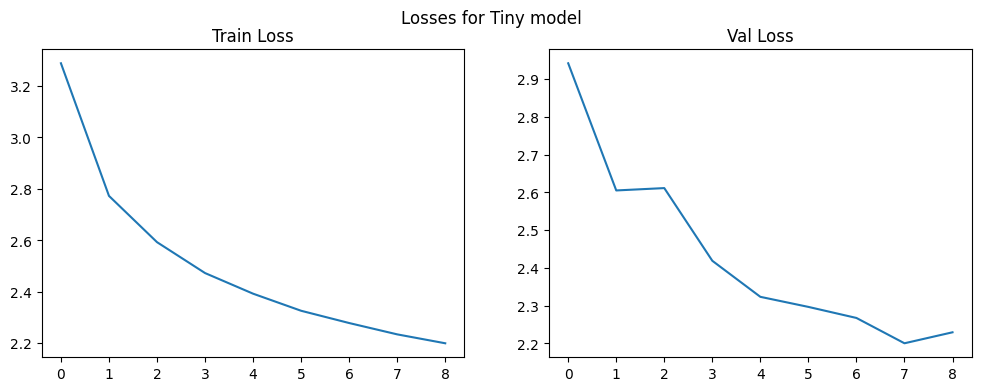

In [56]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
fig.suptitle("Losses for Tiny model")

ax[0].set_title("Train Loss")
ax[0].plot(train_loss)

ax[1].set_title("Val Loss")
ax[1].plot(val_loss)

In [65]:
final_loss_tiny = train_loss[-1]

### Small

In [26]:

model = Transformer(
    embed_dim=128,
    vocab_size_src=tkz_en.get_vocab_size(),
    vocab_size_tgt=tkz_de.get_vocab_size(),
    key_dim=128,
    value_dim=128,
    num_heads=4,
    num_encoder_layers=2,
    num_decoder_layers=2,
    max_seq_len=250
)

In [27]:
non_embedding_params["small"] = 0
for name, param in model.named_parameters():
    if "embedding" not in name and param.requires_grad:  # Exclude embedding parameters
        non_embedding_params["small"] += param.numel()

In [104]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loss = []
val_loss = []

In [105]:
new_train_loss, new_val_loss = train(model, device, train_loader, val_loader, num_epochs=4, learning_rate=0.001, early_stop=False)
train_loss.extend(new_train_loss)
val_loss.extend(new_val_loss)

100%|██████████| 4/4 [07:02<00:00, 105.58s/it]


In [106]:
model.to("cpu")
torch.save({"loss": train_loss, "val_loss": val_loss,  "model": model.state_dict()}, "small.pt")
model.to("cuda")

Transformer(
  (embedding_src): Embedding(20000, 128, padding_idx=1)
  (embedding_trg): Embedding(20000, 128, padding_idx=1)
  (pe): PositionalEmbedding()
  (encoder_layers): ModuleList(
    (0-1): 2 x Encoder(
      (MHA): MultiHeadAttention(
        (k_proj): ModuleList(
          (0-3): 4 x Linear(in_features=32, out_features=128, bias=True)
        )
        (q_proj): ModuleList(
          (0-3): 4 x Linear(in_features=32, out_features=128, bias=True)
        )
        (v_proj): ModuleList(
          (0-3): 4 x Linear(in_features=32, out_features=128, bias=True)
        )
        (out): Linear(in_features=512, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=128, bias=True)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (drop1): Dro

In [107]:
small_pt = torch.load("small.pt", weights_only=False)
train_loss = small_pt["loss"]
val_loss = small_pt["val_loss"]

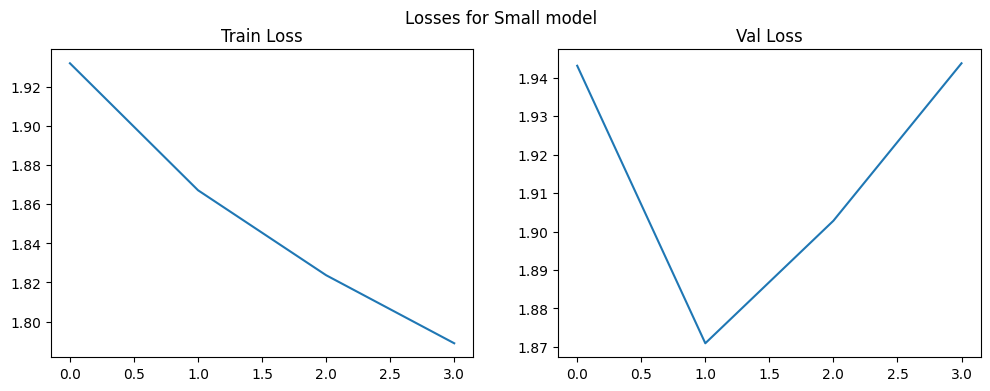

In [108]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
fig.suptitle("Losses for Small model")

ax[0].set_title("Train Loss")
ax[0].plot(train_loss)

ax[1].set_title("Val Loss")
ax[1].plot(val_loss)

In [109]:
final_loss_small = train_loss[-1]

### Medium

In [28]:

model = Transformer(
    embed_dim=256,
    vocab_size_src=tkz_en.get_vocab_size(),
    vocab_size_tgt=tkz_de.get_vocab_size(),
    key_dim=256,
    value_dim=256,
    num_heads=8,
    num_encoder_layers=1,
    num_decoder_layers=1,
    max_seq_len=250
)

In [29]:
non_embedding_params["medium"] = 0
for name, param in model.named_parameters():
    if "embedding" not in name and param.requires_grad:  # Exclude embedding parameters
        non_embedding_params["medium"] += param.numel()

In [30]:
non_embedding_params

{'tiny': 1544608, 'small': 3544352, 'medium': 7850272}

In [77]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loss = []
val_loss = []

In [84]:
new_train_loss, new_val_loss = train(model, device, train_loader, val_loader, num_epochs=4, learning_rate=0.001, early_stop=False)
train_loss.extend(new_train_loss)
val_loss.extend(new_val_loss)

100%|██████████| 1/1 [02:06<00:00, 126.10s/it]


In [85]:
model.to("cpu")
torch.save({"loss": train_loss, "val_loss": val_loss,  "model": model.state_dict()}, "medium.pt")
model.to("cuda")

Transformer(
  (embedding_src): Embedding(20000, 256, padding_idx=1)
  (embedding_trg): Embedding(20000, 256, padding_idx=1)
  (pe): PositionalEmbedding()
  (encoder_layers): ModuleList(
    (0): Encoder(
      (MHA): MultiHeadAttention(
        (k_proj): ModuleList(
          (0-7): 8 x Linear(in_features=32, out_features=256, bias=True)
        )
        (q_proj): ModuleList(
          (0-7): 8 x Linear(in_features=32, out_features=256, bias=True)
        )
        (v_proj): ModuleList(
          (0-7): 8 x Linear(in_features=32, out_features=256, bias=True)
        )
        (out): Linear(in_features=2048, out_features=256, bias=True)
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=256, out_features=512, bias=True)
        (1): ReLU()
        (2): Linear(in_features=512, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (drop1): Dropout(

In [86]:
medium_pt = torch.load("medium.pt", weights_only=False)
train_loss = medium_pt["loss"]
val_loss = medium_pt["val_loss"]

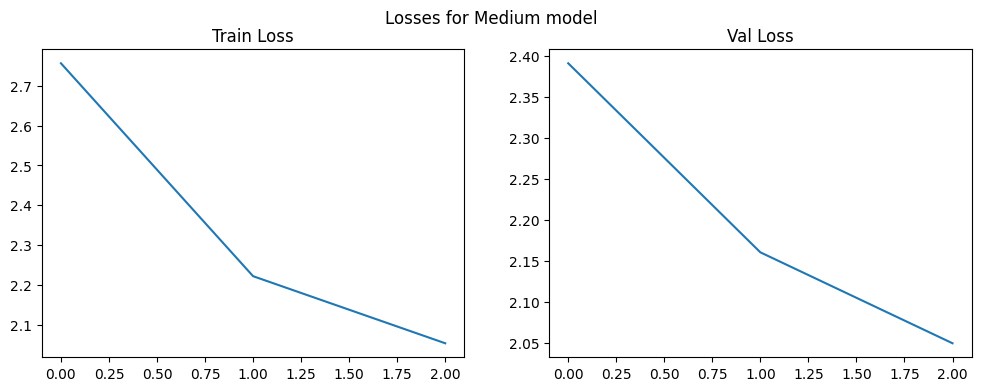

In [87]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
fig.suptitle("Losses for Medium model")

ax[0].set_title("Train Loss")
ax[0].plot(train_loss)

ax[1].set_title("Val Loss")
ax[1].plot(val_loss)

In [88]:
final_medium_loss = train_loss[-1]

### Combining results

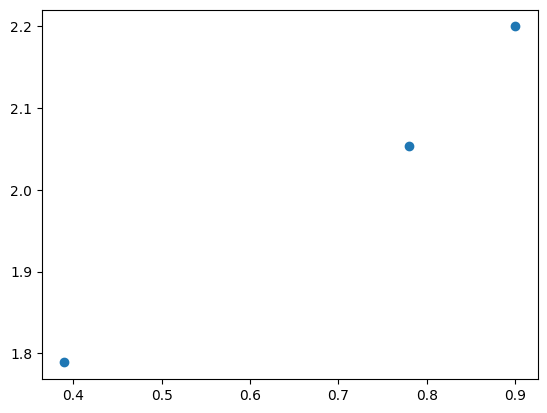

In [110]:
loss_dict_1 = {
    0.9: final_loss_tiny,
    0.39: final_loss_small,
    0.78: final_medium_loss
}
plt.scatter(loss_dict_1.keys(), loss_dict_1.values())

## Law 2
### Performance with Dataset Size D

$$
L(N) \approx \left( \frac{D_c}{D} \right) ^{α_D}
$$


According to this law, given that the number of parameters N is fixed and sufficient and the compute budget is optimal, the Loss follows a power law of D (the number of non-embedding parameters)



Again, we will use 4 different dataset sizes to demonstrate this power law.
The model size would be way less than the original paper and hence α may not completely match.

The caveat in this one is that we will fix the number of epochs to be 1 in all cases. In that way, $S$ (training steps) will increase, hence compute remains optimal (since batch size $B$ will be fixed, and dataset size $D$ increases therefore $S$ increases.

**Fixed Model Size**
    
$d_{model} = 128$, $ n_h = 4 $, $ n_{layer} = 2 $
    
So, $ N \approx 12 \cdot 2 \cdot 128^2 \approx 0.39M $

**Models Used**

- **Tiny**
    
    $D = 10,000$ sentence pairs

- **Small**
    
    $D = 25,000$ sentence pairs
    
- **Medium**
    
    $D = 50,000$ sentence pairs

- **Large**
    
    $D = 100,000$ sentence pairs


In [ ]:

model = Transformer(
    embed_dim=128,
    vocab_size_src=tkz_en.get_vocab_size(),
    vocab_size_tgt=tkz_de.get_vocab_size(),
    key_dim=128,
    value_dim=128,
    num_heads=4,
    num_encoder_layers=2,
    num_decoder_layers=2,
    max_seq_len=250
)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Tiny

In [ ]:
train_df, val_df = sample(df, 10000, 0.01)
train_loader = get_loader(train_df, 50)
val_loader = get_loader(val_df, 50)

/tmp/ipython-input-3875357300.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bin'] = pd.cut(df['en_len'], bins=num_bins)
/tmp/ipython-input-3875357300.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('bin', group_keys=False)
/tmp/ipython-input-3875357300.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select t

In [ ]:
train_loss, val_loss = train(model, device, train_loader, val_loader, num_epochs=3, learning_rate=0.001, early_stop=False)

 44%|████▍     | 4/9 [06:46<08:25, 101.10s/it]

In [ ]:
model.to("cpu")
torch.save({"loss": train_loss, "val_loss": val_loss,  "model": model.state_dict()}, "tiny_2.pt")
model.to("cuda")

In [ ]:
final_loss_tiny = train_loss[-1]

### Small

In [ ]:
train_df, val_df = sample(df, 25000, 0.01)
train_loader = get_loader(train_df, 50)
val_loader = get_loader(val_df, 50)

/tmp/ipython-input-3875357300.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bin'] = pd.cut(df['en_len'], bins=num_bins)
/tmp/ipython-input-3875357300.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('bin', group_keys=False)
/tmp/ipython-input-3875357300.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select t

In [ ]:
train_loss, val_loss = train(model, device, train_loader, val_loader, num_epochs=3, learning_rate=0.001, early_stop=False)

 44%|████▍     | 4/9 [06:46<08:25, 101.10s/it]

In [ ]:
model.to("cpu")
torch.save({"loss": train_loss, "val_loss": val_loss,  "model": model.state_dict()}, "small_2.pt")
model.to("cuda")

In [ ]:
final_loss_small = train_loss[-1]